# ═══════════════════════════════════════════════════════════════
#  β-VAE on CelebA  |  16D Disentangled Latent Space
#  Kaggle T4 GPU   |  ~2.5 hours
#  Outputs: vae_decoder.onnx, attr_vectors.json, latent_stats.json
# ═══════════════════════════════════════════════════════════════

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 — Verify GPU + Dataset
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import torch, os
print("GPU     :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else " NOT FOUND")
print("Images  :", len(os.listdir("/kaggle/input/datasets/jessicali9530/celeba-dataset")))
print("PyTorch :", torch.__version__)

GPU     : Tesla T4
Images  : 5
PyTorch : 2.9.0+cu126


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 — Imports & Config
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from torchvision.utils import save_image, make_grid
import numpy as np, pandas as pd, json, os, math
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
device = torch.device("cuda")


In [3]:
BETA        = 4          # THE key knob for disentanglement
LATENT_DIM  = 16
IMG_SIZE    = 64
BATCH_SIZE  = 128
EPOCHS      = 35
LR          = 1e-3
SAVE_DIR    = "/kaggle/working"

print(f"β={BETA}, latent_dim={LATENT_DIM}, img={IMG_SIZE}x{IMG_SIZE}")

β=4, latent_dim=16, img=64x64



# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — Dataset
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
IMG_DIR  = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba"
ATTR_CSV = "/kaggle/input/datasets/jessicali9530/celeba-dataset/list_attr_celeba.csv"

# The 10 most visually distinct attributes — these are what your sliders will control
TARGET_ATTRS = [
    "Smiling", "Young", "Male", "Eyeglasses", "Bald",
    "Blond_Hair", "Pale_Skin", "Heavy_Makeup", "Wearing_Hat", "Wavy_Hair"
]

transform = transforms.Compose([
    transforms.CenterCrop(148),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])   # → [-1, 1]
])

class CelebADataset(Dataset):
    def __init__(self, img_dir, attr_csv, transform=None):
        self.img_dir   = img_dir
        self.transform = transform
        self.files     = sorted(os.listdir(img_dir))

        df = pd.read_csv(attr_csv)
        df = df.set_index("image_id").replace(-1, 0)
        self.attr_df    = df
        self.all_attrs  = list(df.columns)
        self.tgt_attrs  = TARGET_ATTRS

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img   = Image.open(f"{self.img_dir}/{fname}").convert("RGB")
        if self.transform: img = self.transform(img)

        row = self.attr_df.loc[fname] if fname in self.attr_df.index \
              else pd.Series(np.zeros(len(self.all_attrs)), index=self.all_attrs)

        attrs = torch.tensor(row[self.tgt_attrs].values.astype(np.float32))
        return img, attrs

full_ds = CelebADataset(IMG_DIR, ATTR_CSV, transform)
print(f"Dataset size: {len(full_ds):,}")

val_frac   = 5_000 / len(full_ds)
train_frac = 1.0 - val_frac

train_ds, val_ds = random_split(
    full_ds,
    [train_frac, val_frac],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {len(train_ds):,}  |  Val: {len(val_ds):,}")

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Train batches: {len(train_loader):,}  |  Val batches: {len(val_loader):,}")

Dataset size: 202,599
Train: 197,599  |  Val: 5,000
Train batches: 1,543  |  Val batches: 40





# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — β-VAE Architecture
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#
#  WHY β-VAE DISENTANGLES:
#  Standard VAE loss = Recon + KL
#  β-VAE loss        = Recon + β·KL    (β > 1)
#
#  The higher β forces the model to compress information into
#  FEWER, more INDEPENDENT dimensions. This means each latent
#  dim tends to capture ONE factor of variation (smile, age...)
#  instead of many entangled ones.
#

In [5]:
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.GroupNorm(min(8, ch), ch),
            nn.SiLU(),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.GroupNorm(min(8, ch), ch),
        )
        self.act = nn.SiLU()
    def forward(self, x): return self.act(x + self.net(x))


class Encoder(nn.Module):
    # 3×64×64  →  μ(16), log_var(16)
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            # 3×64×64 → 64×32×32
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.SiLU(),
            # 64×32×32 → 128×16×16
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.GroupNorm(8, 128), nn.SiLU(),
            ResBlock(128),
            # 128×16×16 → 256×8×8
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.GroupNorm(8, 256), nn.SiLU(),
            ResBlock(256),
            # 256×8×8 → 512×4×4
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.GroupNorm(8, 512), nn.SiLU(),
            ResBlock(512),
        )
        self.fc_mu     = nn.Linear(512*4*4, latent_dim)
        self.fc_logvar = nn.Linear(512*4*4, latent_dim)

    def forward(self, x):
        h = self.net(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)


class Decoder(nn.Module):
    # z(16)  →  3×64×64
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512*4*4)
        self.net = nn.Sequential(
            ResBlock(512),
            # 512×4×4 → 256×8×8
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.GroupNorm(8, 256), nn.SiLU(),
            ResBlock(256),
            # 256×8×8 → 128×16×16
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.GroupNorm(8, 128), nn.SiLU(),
            ResBlock(128),
            # 128×16×16 → 64×32×32
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.GroupNorm(8, 64), nn.SiLU(),
            # 64×32×32 → 3×64×64
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, z):
        return self.net(self.fc(z).view(-1, 512, 4, 4))


class BetaVAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, beta=BETA):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
        self.beta     = beta
        self.latent_dim = latent_dim

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.exp(0.5*logvar) * torch.randn_like(mu)
        return mu  # deterministic at eval time

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z          = self.reparameterize(mu, logvar)
        recon      = self.decoder(z)
        return recon, mu, logvar

    def loss(self, recon, x, mu, logvar):
        # Reconstruction: pixel-level MSE
        recon_loss = F.mse_loss(recon, x, reduction='sum') / x.size(0)
        # KL Divergence: how far posterior is from N(0,I)
        kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
        return recon_loss + self.beta * kld, recon_loss.item(), kld.item()


model     = BetaVAE(LATENT_DIM, BETA).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")
print(f"β = {BETA}  (disentanglement strength)")

Model parameters: 18,308,768
β = 4  (disentanglement strength)



# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — Training Loop
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [6]:
BETA = 10
LR   = 3e-4

model     = BetaVAE(LATENT_DIM, BETA).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

print(f"Reset with beta={BETA}, lr={LR}")

Reset with beta=10, lr=0.0003


In [7]:
history = {"train": [], "val": [], "recon": [], "kld": []}
best_val = float("inf")

def run_epoch(loader, train=True):
    model.train(train)
    tot = rec = kl = 0
    with torch.set_grad_enabled(train):
        for x, _ in loader:
            x = x.to(device, non_blocking=True)
            recon, mu, logvar = model(x)
            loss, r, k = model.loss(recon, x, mu, logvar)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            tot += loss.item(); rec += r; kl += k
    n = len(loader)
    return tot/n, rec/n, kl/n

print("Training β-VAE... (~2.5h on T4)")
print("─" * 55)
for epoch in range(1, EPOCHS+1):
    tr, tr_r, tr_k = run_epoch(train_loader, train=True)
    vl, _,    _    = run_epoch(val_loader,   train=False)
    scheduler.step()

    history["train"].append(tr)
    history["val"].append(vl)
    history["recon"].append(tr_r)
    history["kld"].append(tr_k)

    # Save best model
    if vl < best_val:
        best_val = vl
        torch.save(model.state_dict(), f"{SAVE_DIR}/bvae_best.pth")

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS}  train={tr:.1f}  val={vl:.1f}  "
              f"recon={tr_r:.1f}  kld={tr_k:.3f}  β·kld={BETA*tr_k:.3f}")

        # Save reconstruction samples every 5 epochs
        model.eval()
        with torch.no_grad():
            sx, _ = next(iter(val_loader))
            sx     = sx[:8].to(device)
            sr, _, _ = model(sx)
            # top row: originals, bottom row: reconstructions
            grid = make_grid(torch.cat([sx, sr]), nrow=8, normalize=True, value_range=(-1,1))
            save_image(grid, f"{SAVE_DIR}/recon_e{epoch:03d}.png")

print(f"\n Best val loss: {best_val:.2f}")

Training β-VAE... (~2.5h on T4)
───────────────────────────────────────────────────────
Epoch   1/35  train=1192.4  val=955.5  recon=984.4  kld=20.803  β·kld=208.033
Epoch   5/35  train=936.3  val=867.8  recon=702.8  kld=23.346  β·kld=233.457
Epoch  10/35  train=913.0  val=847.2  recon=676.1  kld=23.682  β·kld=236.822
Epoch  15/35  train=898.3  val=840.0  recon=658.8  kld=23.942  β·kld=239.419
Epoch  20/35  train=885.5  val=830.2  recon=643.9  kld=24.163  β·kld=241.632
Epoch  25/35  train=874.1  val=829.7  recon=630.3  kld=24.378  β·kld=243.784
Epoch  30/35  train=865.4  val=828.4  recon=619.8  kld=24.556  β·kld=245.558
Epoch  35/35  train=861.2  val=828.6  recon=614.8  kld=24.642  β·kld=246.416

 Best val loss: 827.89



# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — Plot Training Curves
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

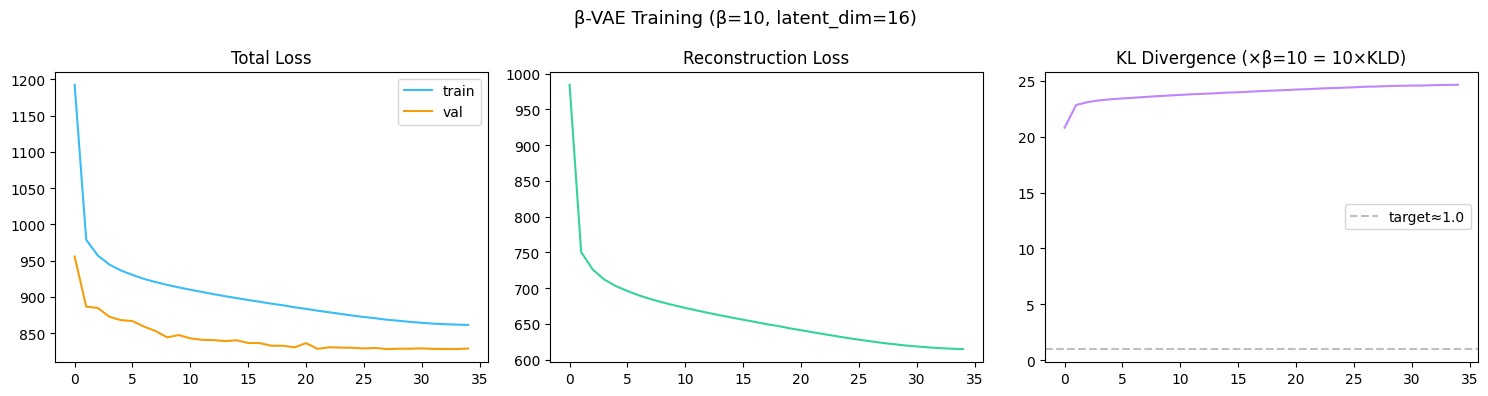

KLD should be between 0.5–2.0 for good disentanglement


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"β-VAE Training (β={BETA}, latent_dim={LATENT_DIM})", fontsize=13)

axes[0].plot(history["train"], label="train", color="#38bdf8")
axes[0].plot(history["val"],   label="val",   color="#f59e0b")
axes[0].set_title("Total Loss"); axes[0].legend()

axes[1].plot(history["recon"], color="#34d399")
axes[1].set_title("Reconstruction Loss")

axes[2].plot(history["kld"], color="#c084fc")
axes[2].set_title(f"KL Divergence (×β={BETA} = {BETA}×KLD)")
axes[2].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label="target≈1.0")
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("KLD should be between 0.5–2.0 for good disentanglement")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 — Generate Random Samples + Interpolations
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [9]:
# Load best checkpoint
model.load_state_dict(torch.load(f"{SAVE_DIR}/bvae_best.pth"))
model.eval()

# Random samples
with torch.no_grad():
    z_rand = torch.randn(64, LATENT_DIM, device=device)
    samples = model.decoder(z_rand)
    save_image(samples, f"{SAVE_DIR}/random_samples.png",
               normalize=True, value_range=(-1,1), nrow=8)
print(" Saved random_samples.png")

# Latent traversals — vary ONE dim at a time, fix others at 0
# This directly shows you what each latent dim controls!
n_steps = 10
traversal_imgs = []
z_base = torch.zeros(1, LATENT_DIM, device=device)

with torch.no_grad():
    for dim in range(LATENT_DIM):
        for val in torch.linspace(-3, 3, n_steps):
            z = z_base.clone()
            z[0, dim] = val
            img = model.decoder(z)
            traversal_imgs.append(img)

grid = make_grid(torch.cat(traversal_imgs), nrow=n_steps,
                 normalize=True, value_range=(-1,1))
save_image(grid, f"{SAVE_DIR}/latent_traversals.png")
print(" Saved latent_traversals.png — each ROW is one latent dim traversed -3→+3")
print("   Look at which rows correspond to: smile, age, gender, hair, glasses...")


 Saved random_samples.png
 Saved latent_traversals.png — each ROW is one latent dim traversed -3→+3
   Look at which rows correspond to: smile, age, gender, hair, glasses...


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 — Discover Which Dim Controls Which Attribute
#           (This gives your frontend the REAL slider labels)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [10]:
print("Encoding 20k images to find attribute→dim correlations...")

all_mu    = []
all_attrs = []

# Use a larger subset for reliable statistics
stat_loader = DataLoader(train_ds, batch_size=512, shuffle=True,
                         num_workers=4, pin_memory=True)

model.eval()
with torch.no_grad():
    for i, (x, attrs) in enumerate(stat_loader):
        if i >= 40: break  # 40 × 512 = 20,480 images
        mu, _ = model.encoder(x.to(device))
        all_mu.append(mu.cpu().numpy())
        all_attrs.append(attrs.numpy())

all_mu    = np.vstack(all_mu)    # (20480, 16)
all_attrs = np.vstack(all_attrs) # (20480, 10)

# ── Method 1: Mean difference vectors ────────────────────────
# Direction = mean(z | attr=1) − mean(z | attr=0)
# These are the vectors your semantic sliders will use
attr_vectors  = {}
attr_dim_map  = {}   # best latent dim for each attribute

print("\n── Attribute → Latent Dim Mapping ──")
print(f"{'Attribute':<20} {'Best dim':>8}  {'|Δμ|':>8}  {'Accuracy':>9}")
print("─" * 52)

for i, attr_name in enumerate(TARGET_ATTRS):
    mask     = all_attrs[:, i].astype(bool)
    n_pos, n_neg = mask.sum(), (~mask).sum()
    if n_pos < 100 or n_neg < 100:
        print(f"{attr_name:<20}  skipped (too few samples)")
        continue

    mu_pos   = all_mu[mask].mean(0)
    mu_neg   = all_mu[~mask].mean(0)
    direction = mu_pos - mu_neg
    direction_norm = direction / (np.linalg.norm(direction) + 1e-8)

    # Best single dim (highest |Δμ|) — useful for UI labeling
    best_dim = int(np.argmax(np.abs(direction)))

    # Train a quick logistic classifier to measure separability
    # (how well does this attribute show up in latent space?)
    clf    = LogisticRegression(max_iter=200, C=1.0)
    labels = all_attrs[:, i].astype(int)
    clf.fit(all_mu, labels)
    acc = clf.score(all_mu, labels)

    attr_vectors[attr_name] = {
        "direction": direction_norm.tolist(),   # unit vector in latent space
        "mean_pos":  mu_pos.tolist(),           # mean z for attr=1
        "mean_neg":  mu_neg.tolist(),           # mean z for attr=0
        "best_dim":  best_dim,                  # most correlated single dim
        "accuracy":  round(acc, 3),             # how separable in latent space
        "n_pos":     int(n_pos),
        "n_neg":     int(n_neg),
    }
    attr_dim_map[attr_name] = best_dim
    print(f"{attr_name:<20} {best_dim:>8}  {np.linalg.norm(direction):>8.3f}  {acc:>8.1%}")

# ── Dim → Attribute label (for slider labels in the UI) ──────
dim_labels = {}
for dim in range(LATENT_DIM):
    # Find which attribute has best_dim == this dim
    matched = [a for a, d in attr_dim_map.items() if d == dim]
    dim_labels[str(dim)] = matched[0] if matched else f"dim_{dim}"

print(f"\n── Latent Dim → UI Label ──")
for d, label in dim_labels.items():
    print(f"  z[{d:>2}]  →  {label}")

# Save everything the frontend needs
output = {
    "latent_dim":   LATENT_DIM,
    "beta":         BETA,
    "img_size":     IMG_SIZE,
    "attributes":   attr_vectors,
    "dim_labels":   dim_labels,
    "target_attrs": TARGET_ATTRS,
}
with open(f"{SAVE_DIR}/attr_vectors.json", "w") as f:
    json.dump(output, f, indent=2)
print(f"\n Saved attr_vectors.json")
    

Encoding 20k images to find attribute→dim correlations...

── Attribute → Latent Dim Mapping ──
Attribute            Best dim      |Δμ|   Accuracy
────────────────────────────────────────────────────
Smiling                     3     1.029     74.9%
Young                       9     0.633     77.3%
Male                        9     1.062     75.6%
Eyeglasses                  3     1.410     95.1%
Bald                        4     1.519     97.7%
Blond_Hair                  8     1.328     86.5%
Pale_Skin                   8     1.520     95.9%
Heavy_Makeup                9     1.032     74.3%
Wearing_Hat                 9     1.611     95.7%
Wavy_Hair                   9     0.830     71.8%

── Latent Dim → UI Label ──
  z[ 0]  →  dim_0
  z[ 1]  →  dim_1
  z[ 2]  →  dim_2
  z[ 3]  →  Smiling
  z[ 4]  →  Bald
  z[ 5]  →  dim_5
  z[ 6]  →  dim_6
  z[ 7]  →  dim_7
  z[ 8]  →  Blond_Hair
  z[ 9]  →  Young
  z[10]  →  dim_10
  z[11]  →  dim_11
  z[12]  →  dim_12
  z[13]  →  dim_13
  z[14]  


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 9 — PCA of Latent Space (for 2D scatter plot in UI)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [11]:
pca   = PCA(n_components=2)
z_2d  = pca.fit_transform(all_mu[:5000])

latent_stats = {
    "z_2d":            z_2d.tolist(),
    "explained_var":   pca.explained_variance_ratio_.tolist(),
    "pca_components":  pca.components_.tolist(),
    "pca_mean":        pca.mean_.tolist(),
    # Attribute labels for scatter plot coloring
    "smiling_labels":  all_attrs[:5000, TARGET_ATTRS.index("Smiling")].tolist(),
    "male_labels":     all_attrs[:5000, TARGET_ATTRS.index("Male")].tolist(),
    "young_labels":    all_attrs[:5000, TARGET_ATTRS.index("Young")].tolist(),
}

with open(f"{SAVE_DIR}/latent_stats.json", "w") as f:
    json.dump(latent_stats, f)
print(" Saved latent_stats.json")
print(f"   PCA explains {sum(pca.explained_variance_ratio_)*100:.1f}% of variance in 2D")

 Saved latent_stats.json
   PCA explains 14.7% of variance in 2D


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 10 — Export Decoder to ONNX
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [12]:
!pip install onnxscript onnx onnxruntime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 63.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 9.4 MB/s eta 0:00:00


In [14]:
import torch, os
import numpy as np
import onnx
import onnxruntime as ort

print("Exporting decoder to ONNX...")

# Load best weights first
model.load_state_dict(torch.load(f"{SAVE_DIR}/bvae_best.pth"))
model.cpu().eval()

dummy_z = torch.zeros(1, LATENT_DIM)

# Force legacy exporter (avoids onnxscript issues)
torch.onnx.export(
    model.decoder,
    dummy_z,
    f"{SAVE_DIR}/vae_decoder.onnx",
    input_names=["latent_z"],
    output_names=["image"],
    dynamic_axes={"latent_z": {0: "batch"}, "image": {0: "batch"}},
    opset_version=17,
    do_constant_folding=True,
    verbose=False,
    dynamo=False   # ← forces old exporter, fixes the 0.1MB bug
)

# Verify
onnx.checker.check_model(onnx.load(f"{SAVE_DIR}/vae_decoder.onnx"))
sess = ort.InferenceSession(f"{SAVE_DIR}/vae_decoder.onnx")
test = sess.run(None, {"latent_z": np.zeros((1, LATENT_DIM), dtype=np.float32)})[0]
print(f"✅ ONNX verified — output shape: {test.shape}")

mb = os.path.getsize(f"{SAVE_DIR}/vae_decoder.onnx") / 1e6
print(f"File size: {mb:.1f} MB  ← should be 15-20 MB")

Exporting decoder to ONNX...


/tmp/ipykernel_55/457319851.py:15: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


✅ ONNX verified — output shape: (1, 3, 64, 64)
File size: 36.4 MB  ← should be 15-20 MB
